In [ ]:
# ================================================
# PROJECT  : Credit Risk Analysis
# NOTEBOOK : 02 - Data Visualization
# AUTHOR   : Simran Kumari Singh
# TOOL     : Google Colab
# ================================================

In [4]:
# importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('Credit_Risk_Clean.csv')

#Set chart style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded and dataset ready!")
print("shape" , df.shape)

Libraries loaded and dataset ready!
shape (32581, 19)


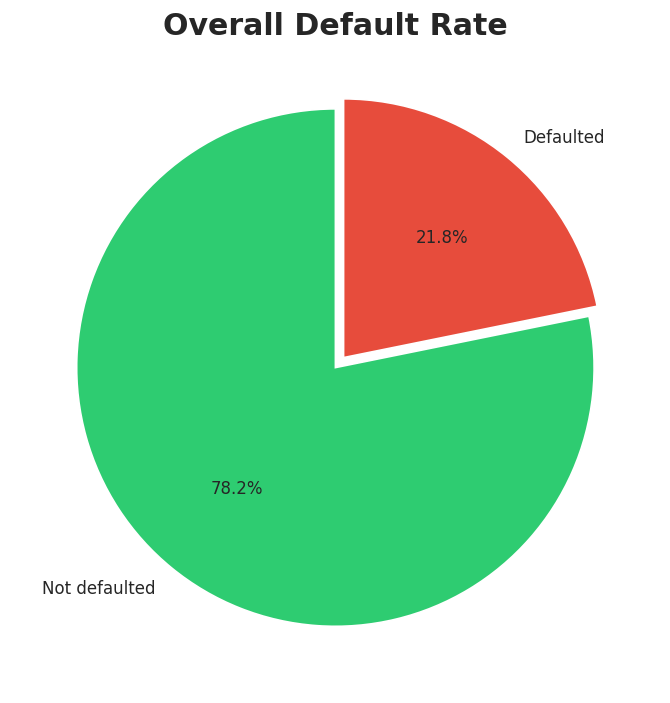

In [53]:
# What percentage defaulted vs did not default?

# 1. Count how many people are in each category (0 = No Default, 1 = Default)
default_counts = df['loan_status'].value_counts()

# 2. Draw a pie chart to see the split
plt.figure(figsize=(7,7))
plt.pie(
    default_counts,
    labels=['Not defaulted','Defaulted'],
    autopct= '%1.1f%%',           # Show the percentage number on the chart
    colors=['#2ecc71','#e74c3c'], # Green for safe, Red for default
    startangle=90,
    explode=(0,0.05)              # Pop the 'Defaulted' slice out a bit
)
plt.title('Overall Default Rate', fontsize=18, fontweight='bold')
plt.show()

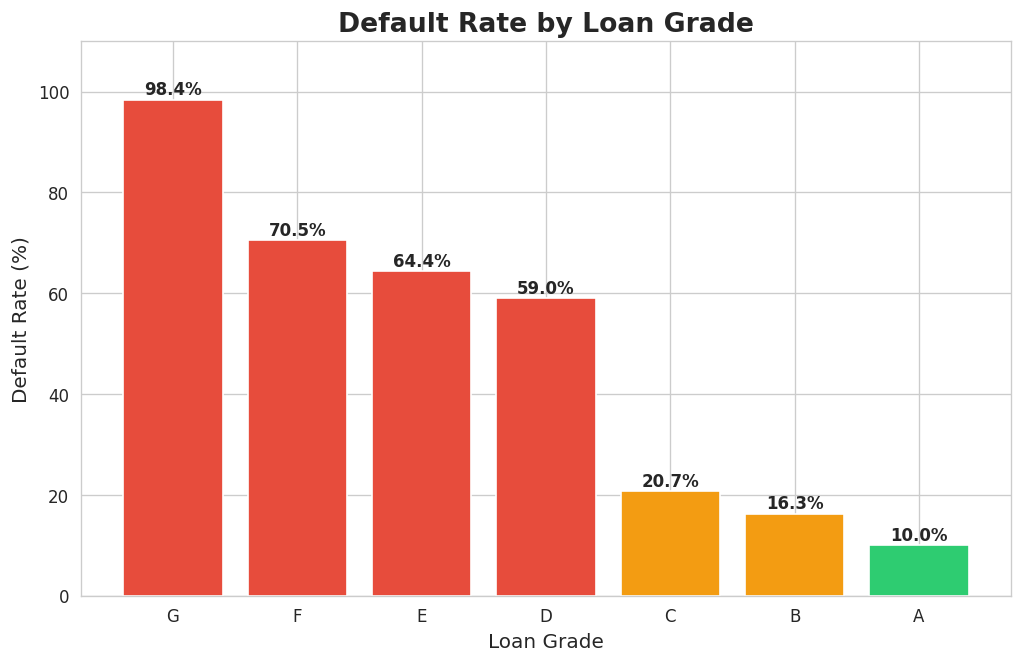

In [54]:
# Which loan grade (risk level assigned by bank) defaults most?

# 1. Group by grade and find the average default rate for each
grade_default = df.groupby('loan_grade')['loan_status'].mean()*100
grade_default = grade_default.reset_index()
grade_default.columns = ['loan_grade','default_rate']
grade_default = grade_default.sort_values('default_rate', ascending=False)

# 2. Create the chart and color code it: Red for high risk, Green for low risk
plt.figure(figsize=(10,6))
bars = plt.bar(
     grade_default['loan_grade'],
     grade_default['default_rate'],
     color=['#e74c3c' if x > 30 else '#f39c12' if x > 15 else '#2ecc71'
            for x in grade_default['default_rate']]
)

# 3. Add titles and labels
plt.title('Default Rate by Loan Grade', fontsize=16, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.ylim(0, 110)

# 4. Put the percentage text on top of each bar
for bar, val in zip(bars,grade_default['default_rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%',
             ha='center', fontsize=10, fontweight='bold')
plt.show()

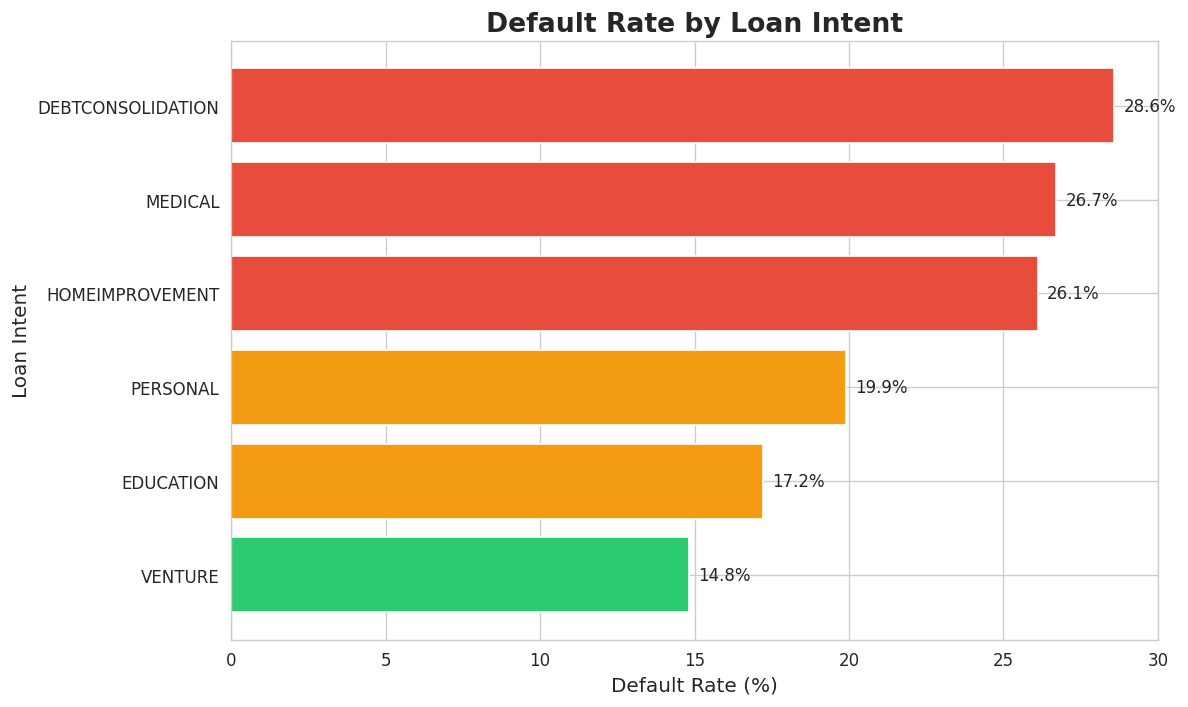

In [55]:
# What was the purpose of the loan for those who defaulted?

# 1. Calculate the percentage of defaults for each loan intent
intent_default = df.groupby('loan_intent')['loan_status'].mean()*100
intent_default = intent_default.reset_index()
intent_default.columns = ['loan_intent','default_rate']
intent_default = intent_default.sort_values('default_rate', ascending=True)

# 2. Create a horizontal bar chart so the long labels are easy to read
plt.figure(figsize=(10,6))
colors = ['#e74c3c' if x > 20 else '#f39c12' if x > 15 else '#2ecc71'
          for x in intent_default['default_rate']]

plt.barh(intent_default['loan_intent'], intent_default['default_rate'],
         color=colors)
plt.title('Default Rate by Loan Intent', fontsize=16, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Loan Intent', fontsize=12)

# 3. Add the percentage numbers next to the bars
for i, val in enumerate(intent_default['default_rate']):
    plt.text(val + 0.3, i, f'{val:.1f}%' , va='center', fontsize=10)

plt.tight_layout()
plt.show()

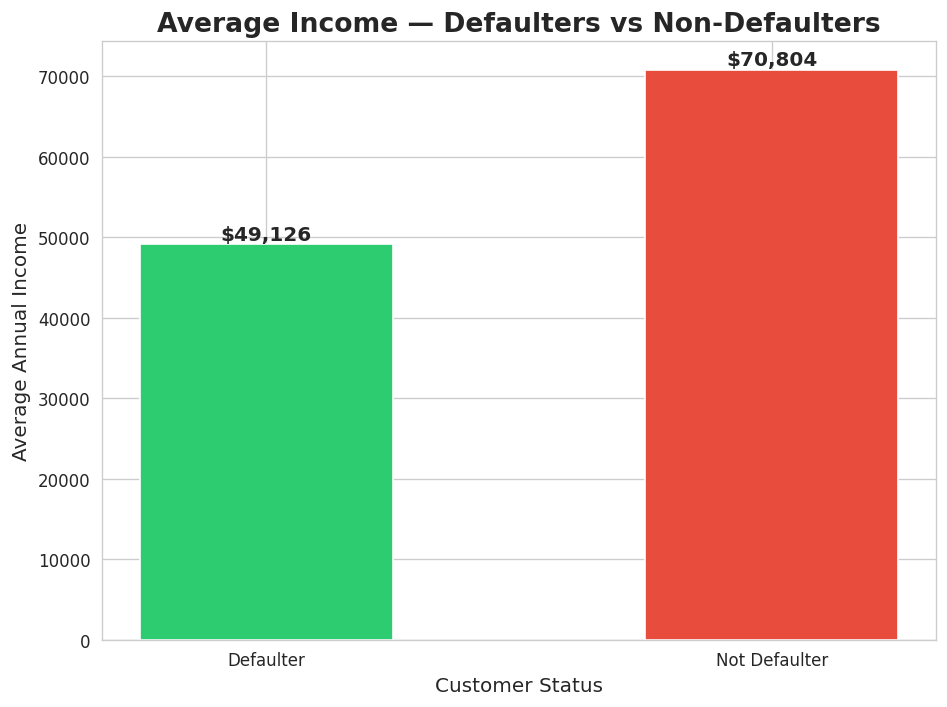

In [56]:
# Do people who default earn less on average?

# 1. Find the average income for defaulters vs non-defaulters
avg_income = df.groupby('default_label')['person_income'].mean().reset_index()

# 2. Plot the comparison
plt.figure(figsize=(8, 6))
bars = plt.bar(
    avg_income['default_label'],
    avg_income['person_income'],
    color=['#2ecc71', '#e74c3c'],
    width=0.5
)

plt.title('Average Income — Defaulters vs Non-Defaulters', fontsize=16,
          fontweight='bold')
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Average Annual Income', fontsize=12)

# 3. Add the exact dollar amount on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f'${height:,.0f}',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

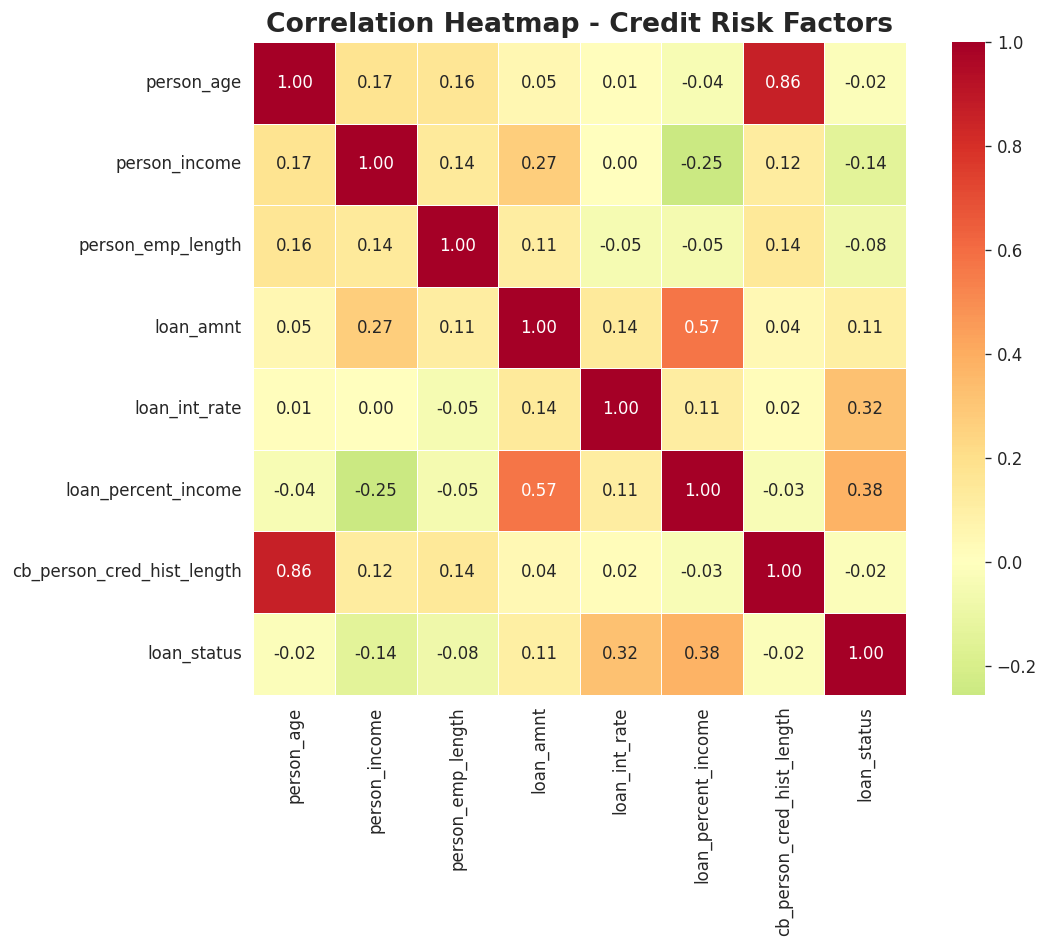

In [57]:
# How strongly is each factor related to another?

# 1. Select the numeric columns we want to compare
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length','loan_status']
correlation = df[numeric_cols].corr()

# 2. Create the heatmap (Red = Positive relationship, Green = Negative)
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation,
    annot=True,     # Show the correlation numbers
    fmt='.2f',
    cmap='RdYlGn_r', # Red to Yellow to Green color map
    center=0,
    square=True,
    linewidth=0.5
)
plt.title('Correlation Heatmap - Credit Risk Factors', fontsize=16,
          fontweight='bold')
plt.tight_layout()
plt.show()

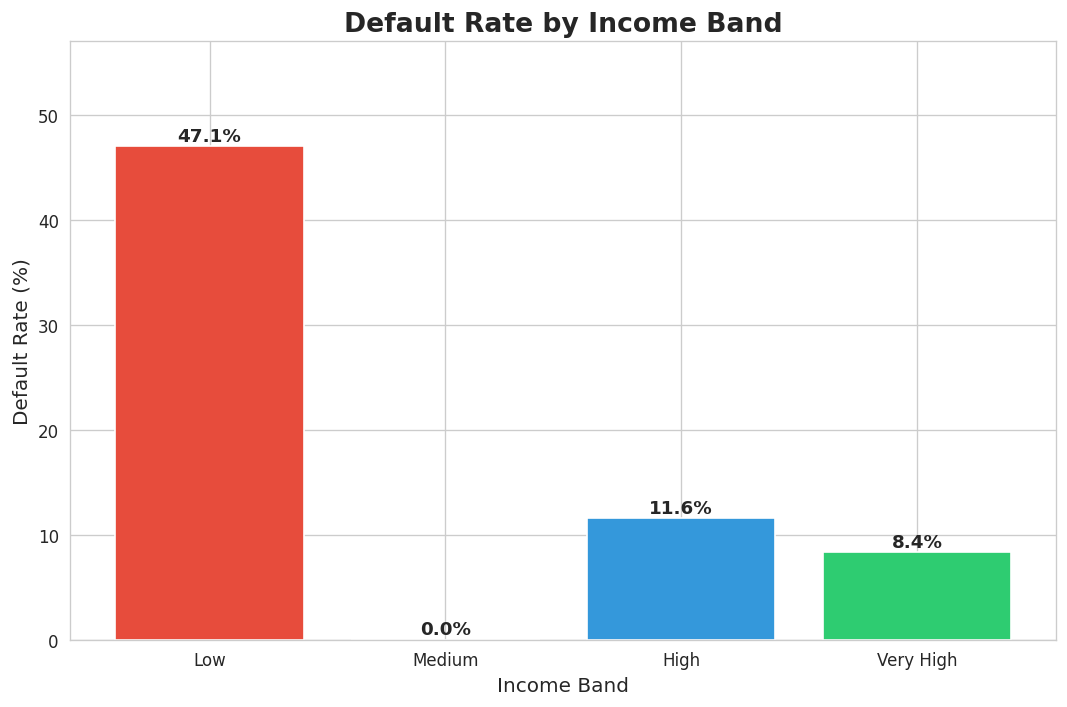

In [37]:
# A closer look: Comparing Default Rates across specific Income Bands

# 1. Filter out missing data and set the order of the categories (Low to Very High)
income_df = df[df['income_band'].notna()].copy()
order = ['Low', 'Medium', 'High', 'Very High']
income_df['income_band'] = pd.Categorical(income_df['income_band'],
                                          categories=order, ordered=True)

# 2. Calculate default percentage for each band
income_default = income_df.groupby('income_band', observed=False)
['loan_status'].mean() * 100
income_default = income_default.reset_index()
income_default.columns = ['income_band', 'default_rate']
income_default['default_rate'] = income_default['default_rate'].fillna(0)

# 3. Create the bar chart
plt.figure(figsize=(9, 6))
bars = plt.bar(
    income_default['income_band'].astype(str),
    income_default['default_rate'],
    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
)

plt.title('Default Rate by Income Band', fontsize=16, fontweight='bold')
plt.xlabel('Income Band', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# 4. Add percentage labels above the bars
for bar, val in zip(bars, income_default['default_rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

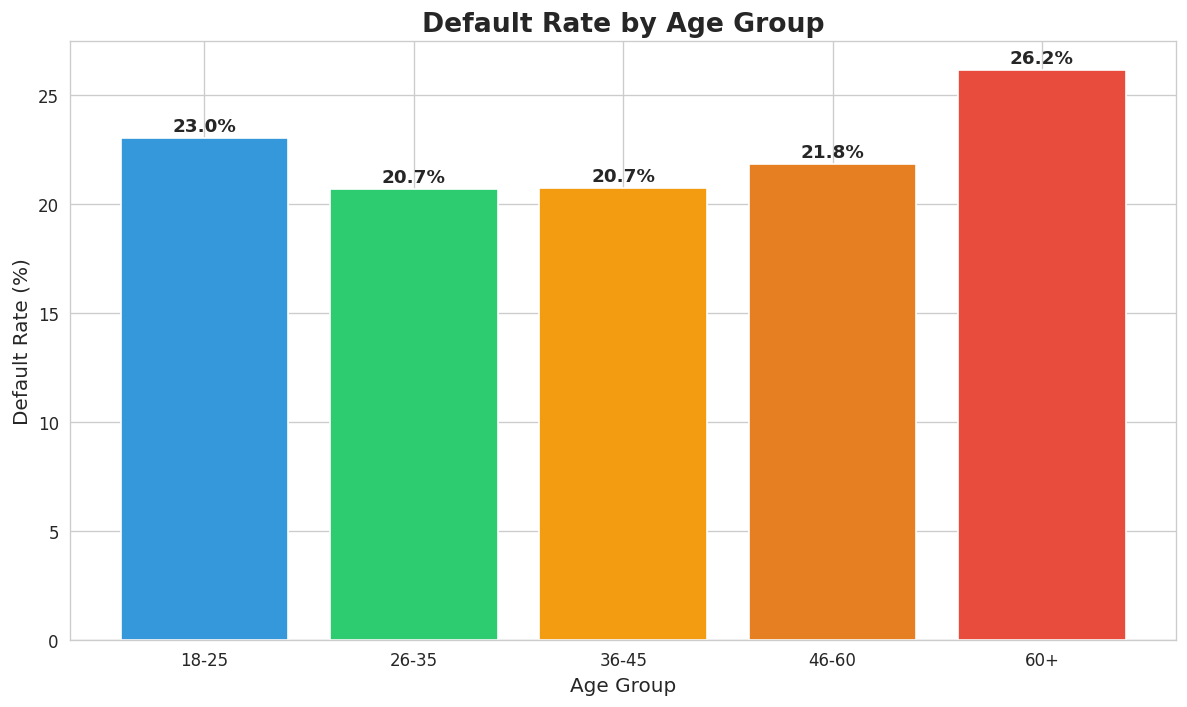

In [50]:
# Which age group defaults most?

# 1. Puts people into categories like '18-25' so we can compare them easily
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[18, 25, 35, 45, 60, 100],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)

# 2. Find out how many people in each group defaulted
age_default = df.groupby('age_group', observed=True)['loan_status'].mean() * 100
age_default = age_default.reset_index()
age_default.columns = ['age_group', 'default_rate']

# 3. Create the bar chart, and colors
plt.figure(figsize=(10,6))
bars = plt.bar(
    age_default['age_group'].astype(str),
    age_default['default_rate'],
    color=['#3498db','#2ecc71','#f39c12','#e67e22','#e74c3c']
)

# 4. Add the title and names for the bottom and side
plt.title('Default Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# 5. Show the exact percentage number above each bar
for bar, val in zip(bars, age_default['default_rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# 6. Make it look neat and show it
plt.tight_layout()
plt.show()

In [51]:
# SAVE ALL CHARTS AS PNG FILES FOR GITHUB

# Chart 1 — Default by Grade
grade_default = df.groupby('loan_grade')['loan_status'].mean() * 100
grade_default = grade_default.reset_index()
grade_default.columns = ['loan_grade', 'default_rate']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(grade_default['loan_grade'], grade_default['default_rate'],
       color='#e74c3c')
ax.set_title('Default Rate by Loan Grade')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate (%)')
fig.savefig('default_by_grade.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 2 — Default by Intent
intent_default = df.groupby('loan_intent')['loan_status'].mean() * 100
intent_default = intent_default.reset_index()
intent_default.columns = ['loan_intent', 'default_rate']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(intent_default['loan_intent'], intent_default['default_rate'],
        color='#3498db')
ax.set_title('Default Rate by Loan Intent')
ax.set_xlabel('Default Rate (%)')
fig.savefig('default_by_intent.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 3 — Average Income Comparison
avg_income = df.groupby('default_label')['person_income'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(avg_income['default_label'], avg_income['person_income'],
       color=['#2ecc71', '#e74c3c'])
ax.set_title('Average Income — Defaulters vs Non-Defaulters')
ax.set_xlabel('Customer Status')
ax.set_ylabel('Average Annual Income')
fig.savefig('income_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

# Chart 4 — Correlation Heatmap
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length', 'loan_status']
correlation = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
fig.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

print("All 4 charts saved successfully!")
print("Go to Files panel on left → right click each PNG → Download")

All 4 charts saved successfully!
Go to Files panel on left → right click each PNG → Download
